# Demo Project Notebook

> *This header was added by `demo_project/TEMPLATE.ipynb`*

Part of the **Demo Project**. CRAFT auto-setup runs shared imports and shows a banner when you open this notebook.

In [4]:
# Setup cell from parent TEMPLATE
# (This cell was prepended by demo_project/TEMPLATE.ipynb)
from dialoghelper import dh_settings
dh_settings['port'] = 8000
print(f'Notebook ready in: {PROJECT_NAME}')

Notebook ready in: Demo Project


In [8]:
import torch; torch.cuda.is_available()

True

In [8]:
from fastai.vision.all import *

In [10]:
path = untar_data(URLs.PETS)

HTML(
<style>
    progress { appearance: none; border: none; border-radius: 4px; width: 300px;
        height: 20px; vertical-align: middle; background: #e0e0e0; }

    progress::-webkit-progress-bar { background: #e0e0e0; border-radius: 4px; }
    progress::-webkit-progress-value { background: #2196F3; border-radius: 4px; }
    progress::-moz-progress-bar { background: #2196F3; border-radius: 4px; }

    progress:not([value]) {
        background: repeating-linear-gradient(45deg, #7e7e7e, #7e7e7e 10px, #5c5c5c 10px, #5c5c5c 20px); }

    progress.progress-bar-interrupted::-webkit-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-webkit-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted { background: #F44336; }    

    table.fastprogress { border-collapse: collapse; margin: 1em 0; font-size: 0.9em; }
    table.fastprogress th, table.fastprogress td { padding: 8px 12px; border: 1px solid #ddd; text-align: left; }
    table.fastprogress thead tr { background: #f8f9fa; font-weight: bold; }
    table.fastprogress tbody tr:nth-of-type(even) { background: #f8f9fa; }
</style>
)

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:15&lt;00:00]</div>

In [11]:
path.ls()

[Path('/root/.fastai/data/oxford-iiit-pet/images'), Path('/root/.fastai/data/oxford-iiit-pet/annotations')]

In [11]:
files = get_image_files(path/"images")
len(files)

7390

In [11]:
files[0],files[6]

(Path('/root/.fastai/data/oxford-iiit-pet/images/Siamese_39.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/american_pit_bull_terrier_4.jpg'))

In [14]:
def label_func(f): return f[0].isupper()

In [15]:
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))

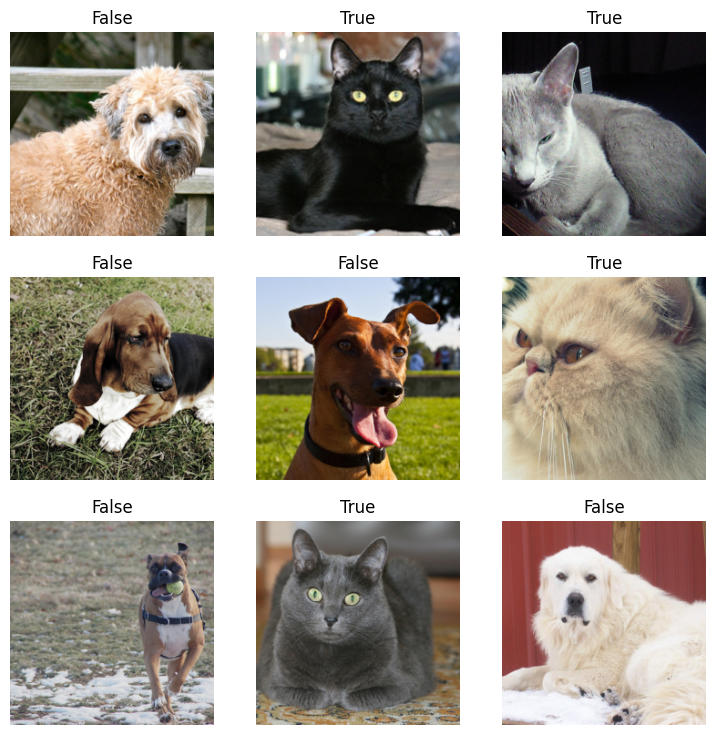

In [16]:
dls.show_batch()

In [17]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

  8%|▊         | 6.50M/83.3M [00:00<00:01, 67.8MB/s]

 16%|█▌        | 13.4M/83.3M [00:00<00:01, 69.8MB/s]

 39%|███▉      | 32.6M/83.3M [00:00<00:00, 130MB/s] 

 66%|██████▌   | 55.0M/83.3M [00:00<00:00, 171MB/s]

 89%|████████▉ | 74.5M/83.3M [00:00<00:00, 183MB/s]

100%|██████████| 83.3M/83.3M [00:00<00:00, 152MB/s]

epoch,train_loss,valid_loss,error_rate,time
0,0.156021,0.026514,0.010825,00:39


epoch,train_loss,valid_loss,error_rate,time
0,0.044976,0.018995,0.007442,00:40


In [17]:
files[0]

Path('/root/.fastai/data/oxford-iiit-pet/images/Siamese_39.jpg')

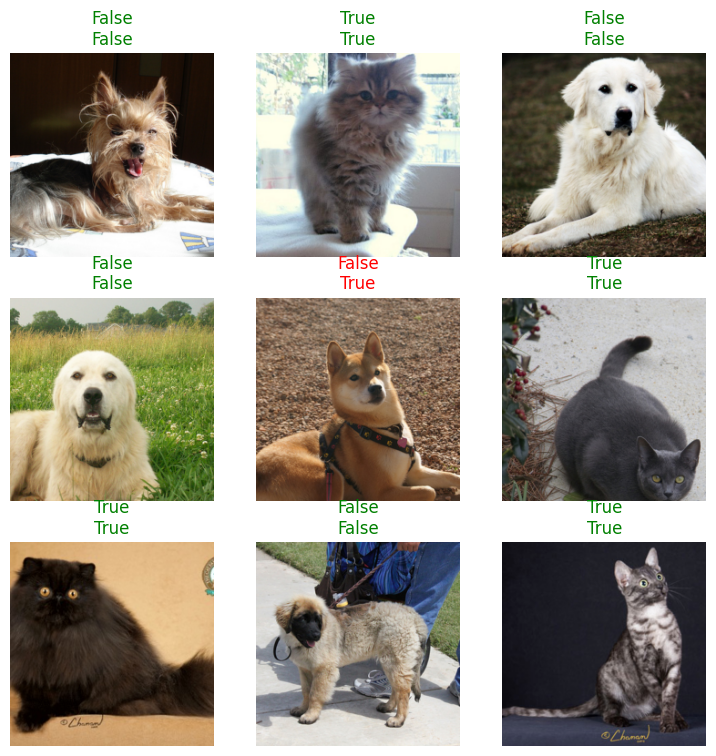

In [19]:
learn.show_results()

In [19]:
files[0].name

'Siamese_39.jpg'

In [19]:
pat = r'^(.*)_\d+.jpg'

In [22]:
dls = ImageDataLoaders.from_name_re(path, files, pat, item_tfms=Resize(224))

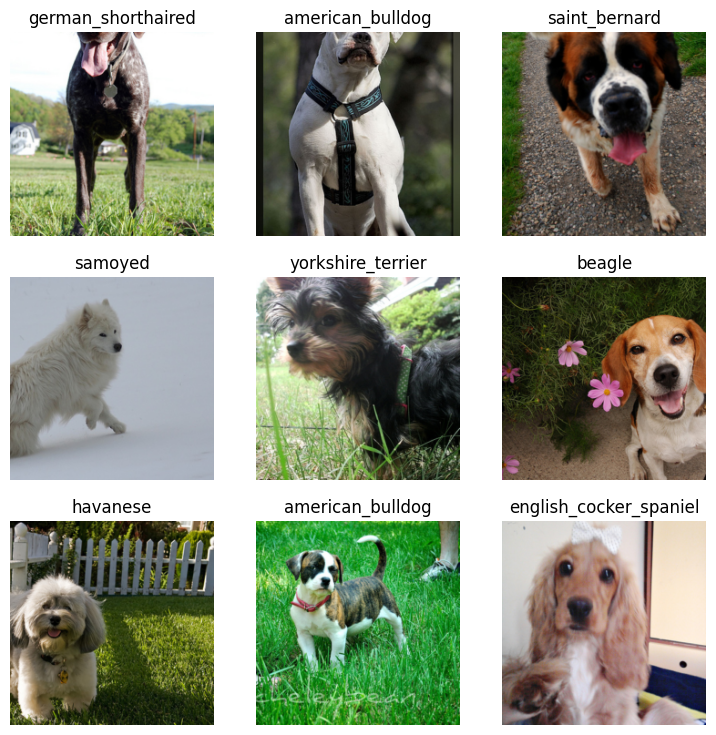

In [23]:
dls.show_batch()

In [24]:
dls = ImageDataLoaders.from_name_re(path, files, pat, item_tfms=Resize(460),
                                    batch_tfms=aug_transforms(size=224))

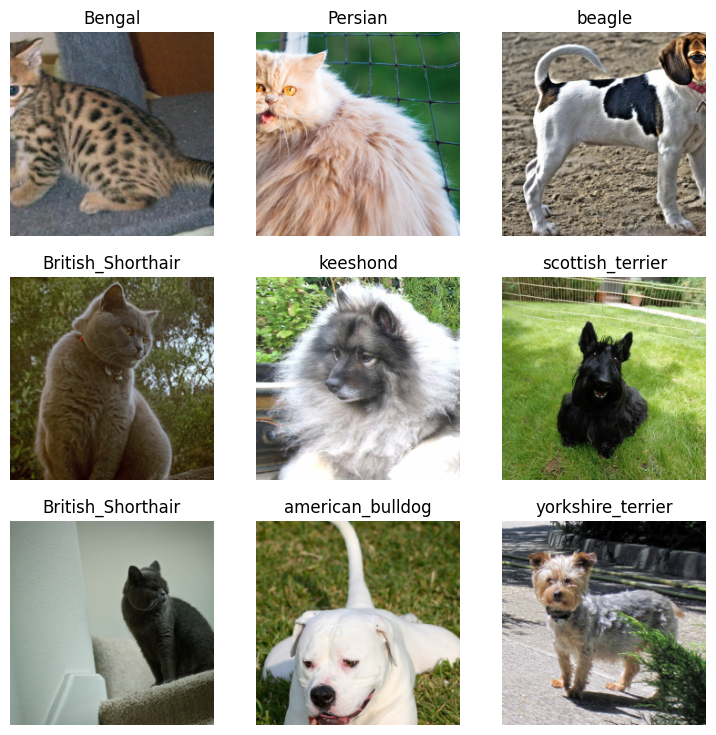

In [25]:
dls.show_batch()

In [26]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

<div></div>

SuggestedLRs(valley=0.0008317637839354575)

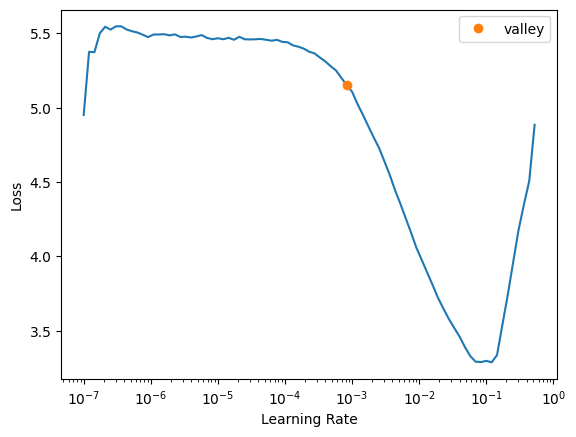

In [27]:
learn.lr_find()

In [27]:
learn.fine_tune(2, 3e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.321279,0.363310,0.114344,00:57


epoch,train_loss,valid_loss,error_rate,time
0,0.549687,0.352635,0.114344,01:01
1,0.326355,0.238430,0.070365,01:01


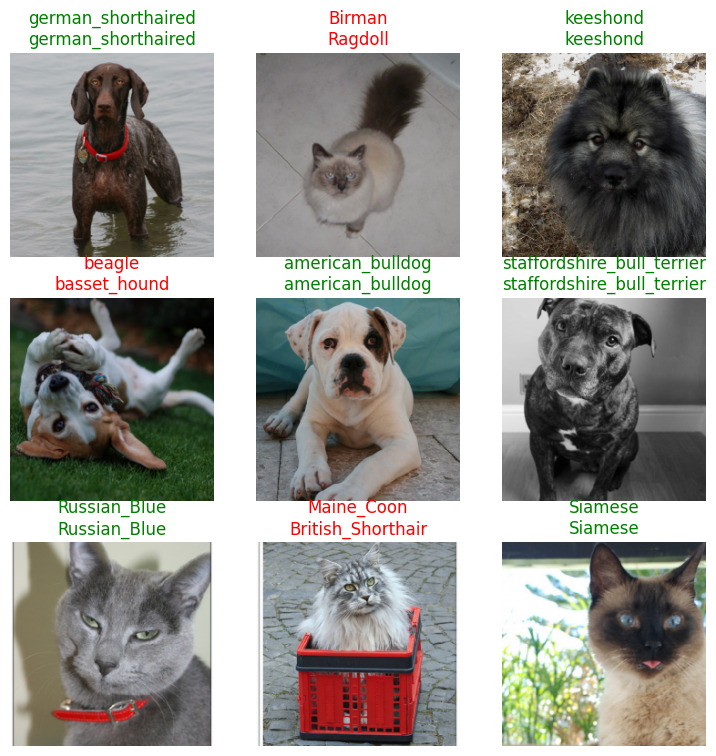

In [29]:
learn.show_results()

In [29]:
interp = Interpretation.from_learner(learn)

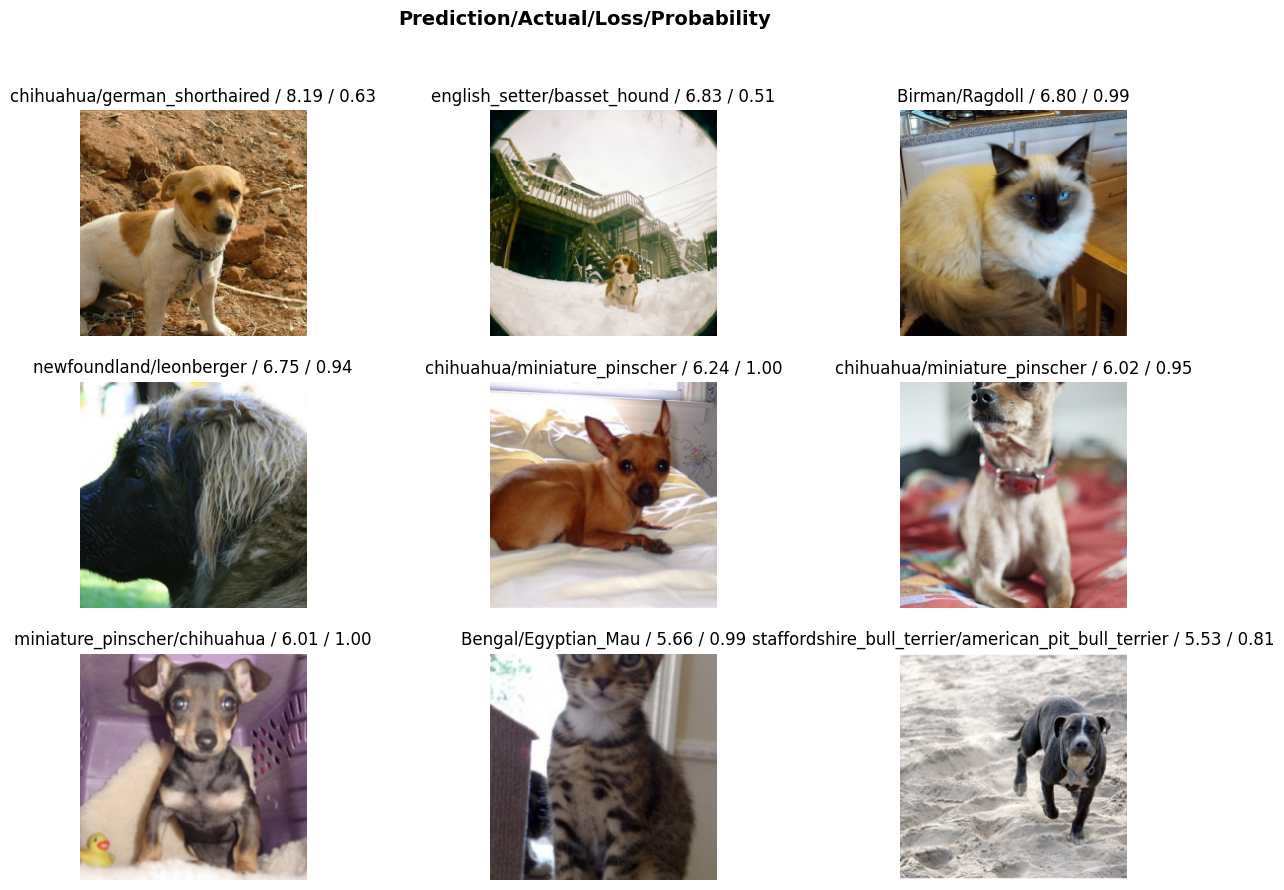

In [31]:
interp.plot_top_losses(9, figsize=(15,10))